# Autoencoder Model Comparison and Final Analysis

## Objective

We compare all anomaly detection experiments, analyze the impact of architectural and training choices, and identify the most effective configuration for degradation detection on the dataset.

The notebook summarizes the results of all autoencoder experiments and provides a final interpretation of the anomaly detection approach.

In [32]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

BASE_DIR = Path("..")

RESULTS_DIR = BASE_DIR / "results"
PLOTS_DIR = BASE_DIR / "plots"
COMPARISON_DIR = PLOTS_DIR / "anomaly_comparison"

COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory:", RESULTS_DIR)
print("Comparison plots directory:", COMPARISON_DIR)

Results directory: ../results
Comparison plots directory: ../plots/anomaly_comparison


## Loading Experiment Results

The autoencoder metrics summary contains the results of all anomaly detection experiments.

In [33]:


summary_path = RESULTS_DIR / "autoencoder_metrics_summary.csv"

summary_df = pd.read_csv(summary_path)

summary_df

,experiment,seq_length,hidden_size,loss,threshold_percentile,precision,recall,f1,roc_auc,average_precision,healthy_mean_error,anomalous_mean_error,denoising,noise_factor,threshold
0,lstm_autoencoder_strict_hidden32_l1,30,32,L1,95,0.972222,0.903226,0.936455,0.983657,0.993945,0.049432,0.095966,0.0,0.00,0.057818
1,lstm_autoencoder_strict_hidden32_l1_denoising,30,32,L1,95,0.971449,0.889032,0.928415,0.980547,0.992773,0.049312,0.092922,1.0,0.01,0.057634
2,lstm_autoencoder_strict_hidden16_l1,30,16,L1,95,0.971325,0.863226,0.914091,0.975362,0.990752,0.049452,0.087457,0.0,0.00,0.057783
3,lstm_autoencoder_strict_hidden32_mse,30,32,MSE,95,0.913621,0.266129,0.412191,0.789735,0.895000,0.006587,0.011006,0.0,0.00,0.013306


## Sorting Experiments

For anomaly detection, the most important metric is the F1-score because it balances precision and recall.

ROC AUC and Average Precision are also considered because they measure ranking quality independently of one fixed threshold.

In [34]:


summary_sorted = summary_df.sort_values(
    by=["f1", "roc_auc", "average_precision"],
    ascending=False
).reset_index(drop=True)

summary_sorted

,experiment,seq_length,hidden_size,loss,threshold_percentile,precision,recall,f1,roc_auc,average_precision,healthy_mean_error,anomalous_mean_error,denoising,noise_factor,threshold
0,lstm_autoencoder_strict_hidden32_l1,30,32,L1,95,0.972222,0.903226,0.936455,0.983657,0.993945,0.049432,0.095966,0.0,0.00,0.057818
1,lstm_autoencoder_strict_hidden32_l1_denoising,30,32,L1,95,0.971449,0.889032,0.928415,0.980547,0.992773,0.049312,0.092922,1.0,0.01,0.057634
2,lstm_autoencoder_strict_hidden16_l1,30,16,L1,95,0.971325,0.863226,0.914091,0.975362,0.990752,0.049452,0.087457,0.0,0.00,0.057783
3,lstm_autoencoder_strict_hidden32_mse,30,32,MSE,95,0.913621,0.266129,0.412191,0.789735,0.895000,0.006587,0.011006,0.0,0.00,0.013306


## Best Model Identification

In [35]:


best_model = summary_sorted.iloc[0]

best_model

experiment              lstm_autoencoder_strict_hidden32_l1
seq_length                                               30
hidden_size                                              32
loss                                                     L1
threshold_percentile                                     95
precision                                          0.972222
recall                                             0.903226
f1                                                 0.936455
roc_auc                                            0.983657
average_precision                                  0.993945
healthy_mean_error                                 0.049432
anomalous_mean_error                               0.095966
denoising                                               0.0
noise_factor                                            0.0
threshold                                          0.057818
Name: 0, dtype: object

In [36]:
print("Best anomaly detection model:")
print("Experiment:", best_model["experiment"])
print("Hidden size:", best_model["hidden_size"])
print("Loss:", best_model["loss"])
print("Denoising:", best_model["denoising"])
print("Precision:", round(best_model["precision"], 4))
print("Recall:", round(best_model["recall"], 4))
print("F1-score:", round(best_model["f1"], 4))
print("ROC AUC:", round(best_model["roc_auc"], 4))
print("Average Precision:", round(best_model["average_precision"], 4))

Best anomaly detection model:
Experiment: lstm_autoencoder_strict_hidden32_l1
Hidden size: 32
Loss: L1
Denoising: 0.0
Precision: 0.9722
Recall: 0.9032
F1-score: 0.9365
ROC AUC: 0.9837
Average Precision: 0.9939


## Overall Metric Comparison

This section compares all anomaly detection experiments using the main classification metrics.

<Figure size 1200x600 with 0 Axes>

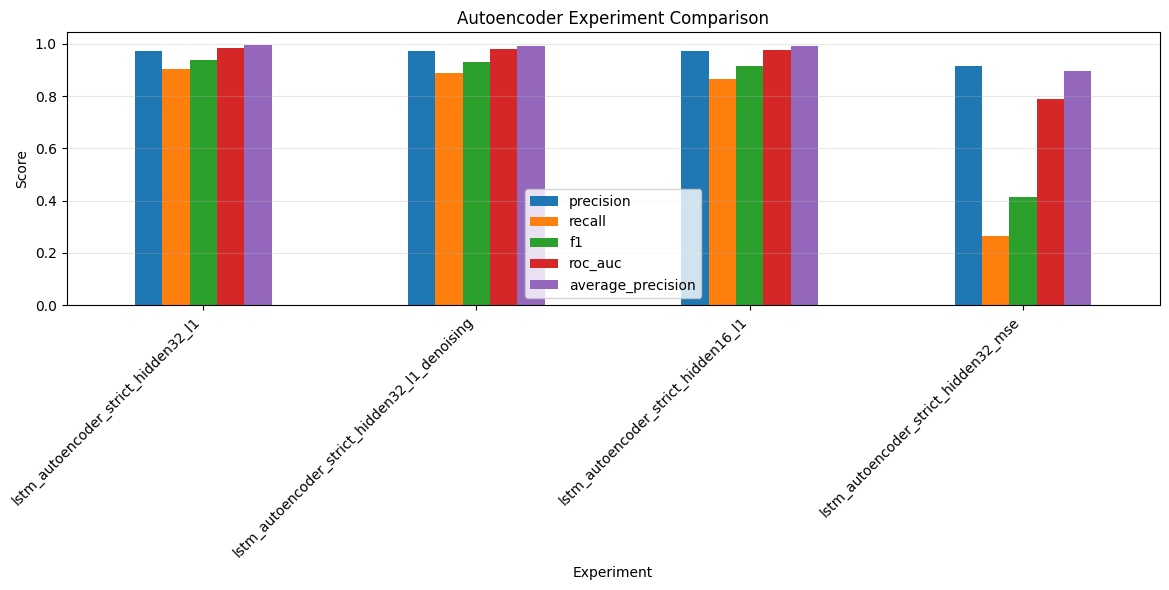

In [37]:


metrics_to_plot = ["precision", "recall", "f1", "roc_auc", "average_precision"]

plot_df = summary_sorted.set_index("experiment")[metrics_to_plot]

plt.figure(figsize=(12, 6))
plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Autoencoder Experiment Comparison")
plt.ylabel("Score")
plt.xlabel("Experiment")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(COMPARISON_DIR / "autoencoder_experiment_comparison.png", dpi=300)
plt.show()

### Observation

The best-performing configuration is selected based on the highest F1-score while also maintaining strong ROC AUC and Average Precision.

The F1-score is especially important because it reflects the balance between detecting degraded sequences and avoiding false alarms.

## Reconstruction Loss Analysis

This section compares the effect of the reconstruction loss function.

The tested losses are:

- MSE loss
- L1 loss

In [38]:

loss_comparison = (
    summary_df
    .groupby("loss")[["precision", "recall", "f1", "roc_auc", "average_precision"]]
    .mean()
    .sort_values("f1", ascending=False)
)

loss_comparison

,precision,recall,f1,roc_auc,average_precision
loss,,,,,
L1,0.971665,0.885161,0.926320,0.979855,0.99249
MSE,0.913621,0.266129,0.412191,0.789735,0.89500


<Figure size 800x500 with 0 Axes>

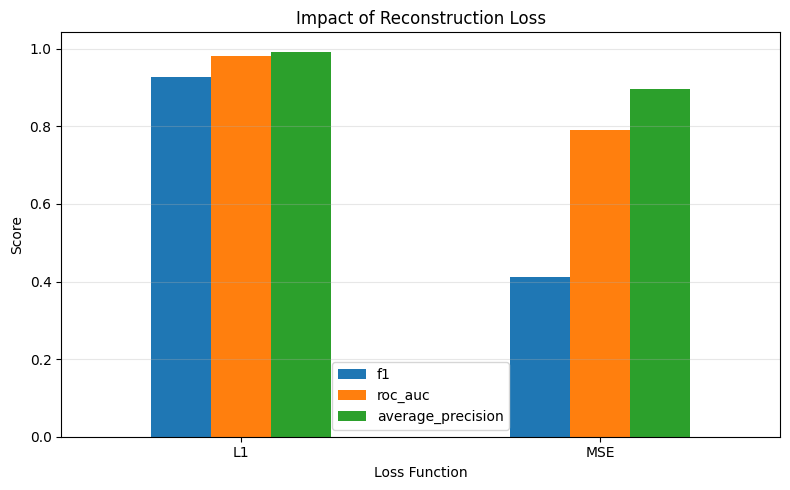

In [39]:
plt.figure(figsize=(8, 5))

loss_comparison[["f1", "roc_auc", "average_precision"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Impact of Reconstruction Loss")
plt.ylabel("Score")
plt.xlabel("Loss Function")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(COMPARISON_DIR / "autoencoder_loss_comparison.png", dpi=300)
plt.show()

### Observation

L1 loss clearly outperformed MSE loss.

The MSE-based autoencoder produced much lower recall and F1-score, indicating that many degraded sequences were not detected.

L1 loss was more effective for this task because it preserved degradation-sensitive reconstruction differences and produced better separation between healthy and anomalous sequences.

## Hidden Size Analysis

This section evaluates the effect of the LSTM hidden size on anomaly detection performance.

In [49]:
# ============================================================
# Hidden size comparison using comparable L1 models
# ============================================================

hidden_df = summary_df[
    summary_df["experiment"].isin([
        "lstm_autoencoder_strict_hidden16_l1",
        "lstm_autoencoder_strict_hidden32_l1"
    ])
].copy()

hidden_comparison = hidden_df.set_index("hidden_size")[
    ["precision", "recall", "f1", "roc_auc", "average_precision"]
]

hidden_comparison

,precision,recall,f1,roc_auc,average_precision
hidden_size,,,,,
32,0.972222,0.903226,0.936455,0.983657,0.993945
16,0.971325,0.863226,0.914091,0.975362,0.990752


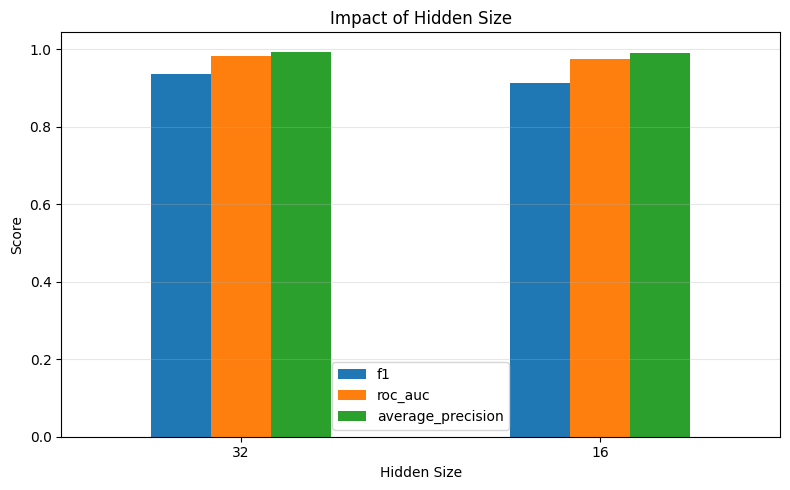

In [50]:
hidden_comparison[["f1", "roc_auc", "average_precision"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Impact of Hidden Size")
plt.ylabel("Score")
plt.xlabel("Hidden Size")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(COMPARISON_DIR / "autoencoder_hidden_size_comparison.png", dpi=300)
plt.show()

### Observation

To evaluate the effect of hidden size, two comparable L1 autoencoder models without denoising were compared.

The hidden size 32 configuration achieved better F1-score, ROC AUC, and Average Precision than the hidden size 16 configuration.

This suggests that hidden size 32 provided a better balance between compression and reconstruction capacity. The smaller hidden size still performed well, but it reduced the model's ability to represent healthy engine behavior accurately enough for optimal anomaly separation.

## Denoising Analysis

This section compares standard autoencoder training with denoising autoencoder training.

In [42]:


denoising_df = summary_df[
    summary_df["experiment"].isin([
        "lstm_autoencoder_strict_hidden32_l1",
        "lstm_autoencoder_strict_hidden32_l1_denoising"
    ])
].copy()

denoising_df[
    [
        "experiment",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision"
    ]
]

,experiment,precision,recall,f1,roc_auc,average_precision
0,lstm_autoencoder_strict_hidden32_l1,0.972222,0.903226,0.936455,0.983657,0.993945
1,lstm_autoencoder_strict_hidden32_l1_denoising,0.971449,0.889032,0.928415,0.980547,0.992773


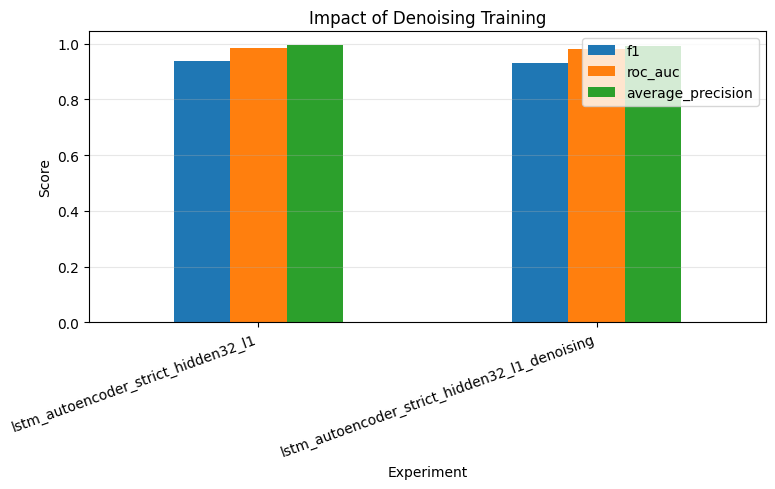

In [43]:
plot_df = denoising_df.set_index("experiment")[
    ["f1", "roc_auc", "average_precision"]
]

plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Impact of Denoising Training")
plt.ylabel("Score")
plt.xlabel("Experiment")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    COMPARISON_DIR / "autoencoder_denoising_comparison.png",
    dpi=300
)

plt.show()

### Observation

To evaluate the effect of denoising, two identical LSTM autoencoder configurations were compared. The only difference between the experiments was the addition of Gaussian noise to the healthy training sequences while keeping the original clean sequences as reconstruction targets.

The standard L1 autoencoder achieved slightly higher F1-score, ROC AUC, and Average Precision than the denoising version.

One possible explanation is that the CMAPSS dataset already contains realistic sensor variability, operational fluctuations, and measurement noise. As a result, the healthy training sequences are not perfectly clean signals. The standard autoencoder was therefore able to learn a robust representation of healthy engine behavior without requiring additional artificial corruption during training.

These results suggest that denoising training did not provide additional benefits in the final strict-label setup. Once healthy and severely degraded operating conditions became clearly separable, the standard L1 autoencoder was sufficient for learning healthy operating patterns and achieving strong anomaly detection performance.

Therefore, the final selected model does not use denoising.

## Final Model Comparison Table

In [44]:


final_table = summary_sorted[
    [
        "experiment",
        "hidden_size",
        "loss",
        "denoising",
        "noise_factor",
        "threshold_percentile",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "healthy_mean_error",
        "anomalous_mean_error"
    ]
].copy()

final_table

,experiment,hidden_size,loss,denoising,noise_factor,threshold_percentile,precision,recall,f1,roc_auc,average_precision,healthy_mean_error,anomalous_mean_error
0,lstm_autoencoder_strict_hidden32_l1,32,L1,0.0,0.00,95,0.972222,0.903226,0.936455,0.983657,0.993945,0.049432,0.095966
1,lstm_autoencoder_strict_hidden32_l1_denoising,32,L1,1.0,0.01,95,0.971449,0.889032,0.928415,0.980547,0.992773,0.049312,0.092922
2,lstm_autoencoder_strict_hidden16_l1,16,L1,0.0,0.00,95,0.971325,0.863226,0.914091,0.975362,0.990752,0.049452,0.087457
3,lstm_autoencoder_strict_hidden32_mse,32,MSE,0.0,0.00,95,0.913621,0.266129,0.412191,0.789735,0.895000,0.006587,0.011006


## Healthy vs Anomalous Reconstruction Error

A good autoencoder anomaly detector should produce lower reconstruction error for healthy sequences and higher reconstruction error for degraded sequences.

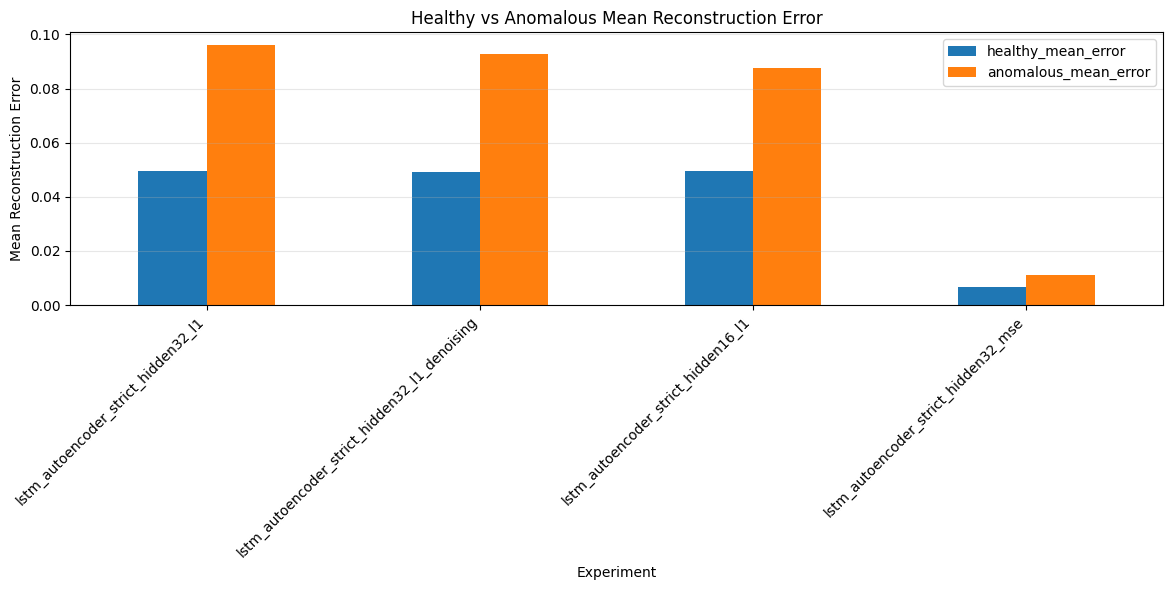

In [45]:


error_df = summary_sorted[
    ["experiment", "healthy_mean_error", "anomalous_mean_error"]
].set_index("experiment")

error_df.plot(kind="bar", figsize=(12, 6))

plt.title("Healthy vs Anomalous Mean Reconstruction Error")
plt.ylabel("Mean Reconstruction Error")
plt.xlabel("Experiment")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(COMPARISON_DIR / "autoencoder_healthy_vs_anomaly_error.png", dpi=300)
plt.show()

### Observation

The best models show a clear gap between healthy and anomalous reconstruction errors.

This confirms that the autoencoder learned healthy engine behavior and produced larger reconstruction errors for degraded sequences.

## Final Model Selection

In [46]:


final_model_summary = pd.DataFrame([{
    "Selected model": best_model["experiment"],
    "Hidden size": best_model["hidden_size"],
    "Loss": best_model["loss"],
    "Denoising": best_model["denoising"],
    "Threshold percentile": best_model["threshold_percentile"],
    "Precision": best_model["precision"],
    "Recall": best_model["recall"],
    "F1-score": best_model["f1"],
    "ROC AUC": best_model["roc_auc"],
    "Average Precision": best_model["average_precision"]
}])

final_model_summary

,Selected model,Hidden size,Loss,Denoising,Threshold percentile,Precision,Recall,F1-score,ROC AUC,Average Precision
0,lstm_autoencoder_strict_hidden32_l1,32,L1,0.0,95,0.972222,0.903226,0.936455,0.983657,0.993945


### Final Selected Configuration

The final selected anomaly detection model is:

- LSTM Autoencoder
- Hidden size: 32
- Reconstruction loss: L1
- Denoising: No
- Threshold: percentile of healthy validation reconstruction errors

This model achieved the best balance between precision, recall, F1-score, ROC AUC, and Average Precision.

## Final Conclusions

The anomaly detection experiments produced several important findings:

1. **The anomaly definition strongly affects performance.**

   The initial anomaly formulation was difficult because degradation in CMAPSS is gradual. By defining healthy sequences as RUL ≥ 120 and anomalous sequences as RUL ≤ 30, the model focused on severe degradation detection.

2. **The autoencoder was trained only on healthy data.**

   This makes the approach a genuine unsupervised anomaly detection method. The model learned normal engine behavior and detected degraded states through increased reconstruction error.

3. **L1 loss outperformed MSE loss.**

   MSE produced much lower recall and F1-score, while L1 loss generated stronger anomaly separation.

4. **Hidden size 32 was the best configuration.**

   It provided enough capacity to model healthy behavior while still preserving a useful bottleneck for anomaly detection.

5. **Denoising was not beneficial in the final setup.**

   The no-denoising L1 model achieved slightly better results.

6. **Reconstruction error behaves as a degradation indicator.**

   The error increases as Remaining Useful Life decreases, showing that the autoencoder can be used not only for binary anomaly detection but also for monitoring degradation progression.

Overall, the LSTM autoencoder successfully detected severe degradation states in the CMAPSS FD001 dataset. However, the method should be interpreted as a severe degradation detector rather than a general early-fault detection system.

In [47]:


output_path = RESULTS_DIR / "autoencoder_final_comparison.csv"

final_table.to_csv(output_path, index=False)

print("Final autoencoder comparison saved to:", output_path)

Final autoencoder comparison saved to: ../results/autoencoder_final_comparison.csv


In [48]:


final_summary_path = RESULTS_DIR / "autoencoder_final_selected_model.csv"

final_model_summary.to_csv(final_summary_path, index=False)

print("Final selected model summary saved to:", final_summary_path)

Final selected model summary saved to: ../results/autoencoder_final_selected_model.csv
